# Stage I - structural MRI measurement differences of numerical variability

### Cohens'd coefficient

Let $X_1$ and $X_2$ represent two distinct populations with $|X_1|=N$, $|X_2|=M$. Cohen's d is defined as:
$$
d = \frac{\mu_1 - \mu_2}{\sigma_{\text{pooled}}},
$$
where $\mu_1$ and $\mu_2$ are the means of populations $X_1$ and $X_2$, respectively, and $\sigma_{\text{pooled}}$ is the pooled standard deviation given by:
$$
\sigma_{\text{pooled}} = \sqrt{\frac{(N-1)\sigma^{2}_{X_1} + (M-1)\sigma^{2}_{X_2}}{N + M - 2}}.
$$

### Cohen's variability

Split population in two equal groups $X_1$, $X_2$.
Compute $N$ times (N being the number of MCA repetitions) the Cohen coefficient.
Compute the standard deviation among the Cohen's d distribution.

In [2]:
import pandas as pd
import os
import plotly.express as px
import numpy as np
from pathlib import Path
from IPython.display import Image

root_dir = Path(os.getcwd())
stats_dir = root_dir / "stats_QCed" / "sampled"
display(f"root directory: {root_dir.as_posix().split('VIP-python-client')[-1]}")
display(f"stats directory: {stats_dir.as_posix().split('VIP-python-client')[-1]}")

'root directory: /example/freesurfer-fuzzy/notebooks'

'stats directory: /example/freesurfer-fuzzy/notebooks/stats_QCed/sampled'

In [198]:
def print_figure(fig, filename):
    display(fig)
    fig.write_image(filename)
    display(Image(filename=filename))

## Compute the two groups among the population

In [16]:
df = pd.read_parquet(stats_dir / "thickness.parquet")
subjects = df["subjects"].unique()
rng = np.random.default_rng(42)
rng.shuffle(subjects)
[pop1, pop2] = np.split(subjects, 2)
print(f"Number of subjects in pop1: {len(pop1)}")
print(f"Number of subjects in pop2: {len(pop2)}")

Number of subjects in pop1: 300
Number of subjects in pop2: 300


In [21]:
def index_by_repetition(df, hemi=None):
    """
    Adds two new columns to the dataframe:
    - 'Rep': Indicates the MCA repetition index for which the subject was sampled.
    - 'Rank': Represents the rank index of the subject among all subjects.
    """
    if hemi is not None:
        # Group by numerical repetition
        df_lh = df[df["hemi"] == "lh"].reset_index(drop=True)
        df_rh = df[df["hemi"] == "rh"].reset_index(drop=True)
        df_lh["Rank"] = (
            df_lh.sort_values(by=["subjects"]).rank(method="dense")["subjects"].astype(int)
        )
        df_rh["Rank"] = (
            df_rh.sort_values(by=["subjects"]).rank(method="dense")["subjects"].astype(int)
        )
        df = pd.concat([df_lh, df_rh], axis=0)
        df["Rep"] = df["Rank"]
        df["Rep"] = (
            df.groupby(["Rank", "hemi"])
            .rank(method="first")["Rep"]
            .reset_index()["Rep"]
            .astype(int)
        )
        return df
    else:
        # Group by MCA repetition
        df["Rank"] = (
            df.sort_values(by=["subjects"])
            .rank(method="first")["subjects"]
            .astype(int)
            .reset_index(drop=True)
        )
        df["Rep"] = df["Rank"]
        df["Rep"] = (
            df.groupby("Rank")
            .rank(method="first")["Rep"]
            .astype(int)
        )
        return df

In [170]:
def compute_stat(df, stat, hemi):
    if hemi:
        stat = (
            df.drop(columns=["Rank", "Rep", "subjects"])
            .groupby(["hemi"])
            .apply(stat)
            .reset_index()
            .melt(id_vars=["hemi"], var_name="ROI", value_name="metric")
        )
    else:
        stat = (
            df.drop(columns=["Rank","Rep","subjects"])
            .apply(stat)
            .reset_index()
            .rename(columns={'index': 'ROI', 0: "metric"})   
        )    
    
    return stat

def compute_mean(df, hemi):
    return compute_stat(df, 'mean', hemi)

def compute_var(df, hemi):
    return compute_stat(df, 'var', hemi)

def compute_std(df, hemi):
    return compute_stat(df, 'std', hemi)



In [ ]:
def compute_cortical_variability_cohen_d(metric, population_1, population_2):
    """
    Computes Cohen's d for the given metric between two populations.
    """
    df = pd.read_parquet(stats_dir / f"{metric}.parquet")

    df = index_by_repetition(df, hemi=True)

    columns = [
        "rep",
        "hemi",
        "ROI",
        "mean_pop1",
        "std_pop1",
        "var_pop1",
        "mean_pop2",
        "std_pop2",
        "var_pop2",
        "pooled_std",
        "cohen_d",
    ]
    cohen_d_df = pd.DataFrame(columns=columns)

    repetitions = df["Rep"].unique()
    for rep in repetitions:

        # Get population 1
        df1_rep = df[df["Rep"] == rep]
        df1_rep = df1_rep[df1_rep["subjects"].isin(population_1)]
        n1 = df1_rep["subjects"].nunique()
        # Compute mean, var, std for population 1
        mean_pop1 = compute_mean(df1_rep, hemi=True)
        var_pop1 = compute_var(df1_rep, hemi=True)
        std_pop1 = compute_std(df1_rep, hemi=True)

        # Get population 2
        df2_rep = df[df["Rep"] == rep]
        df2_rep = df2_rep[df2_rep["subjects"].isin(population_2)]
        n2 = df2_rep["subjects"].nunique()
        # Compute mean, var, std for population 2
        mean_pop2 = compute_mean(df2_rep, hemi=True)
        var_pop2 = compute_var(df2_rep, hemi=True)
        std_pop2 = compute_std(df2_rep, hemi=True)

        pooled_var = ((n1 - 1) * var_pop1.metric + (n2 - 1) * var_pop2.metric) / (
            n1 + n2 - 2
        )
        pooled_std = np.sqrt(pooled_var)
        cohen_d = (mean_pop1.metric - mean_pop2.metric) / pooled_std

        # Create a DataFrame to display the results
        cohen_d_df_rep = pd.DataFrame(columns=columns)
        cohen_d_df_rep["hemi"] = mean_pop1.hemi
        cohen_d_df_rep["ROI"] = mean_pop1.ROI
        cohen_d_df_rep["mean_pop1"] = mean_pop1.metric
        cohen_d_df_rep["std_pop1"] = std_pop1.metric
        cohen_d_df_rep["var_pop1"] = var_pop1.metric
        cohen_d_df_rep["mean_pop2"] = mean_pop2.metric
        cohen_d_df_rep["std_pop2"] = std_pop2.metric
        cohen_d_df_rep["var_pop2"] = var_pop2.metric
        cohen_d_df_rep["pooled_std"] = pooled_std
        cohen_d_df_rep["cohen_d"] = cohen_d
        cohen_d_df_rep["rep"] = rep

        # Append the DataFrame to the main DataFrame
        cohen_d_df = pd.concat([cohen_d_df, cohen_d_df_rep], axis=0)

    cohen_d_df["ROI"] = cohen_d_df["ROI"].str.replace(f"_{metric}", "", regex=False)
    return cohen_d_df.reset_index(drop=True)

### Cortical Thickness

In [143]:
cohen_d_thickness = compute_cortical_variability_cohen_d("thickness", pop1, pop2)

/tmp/ipykernel_187744/2405758577.py:96: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



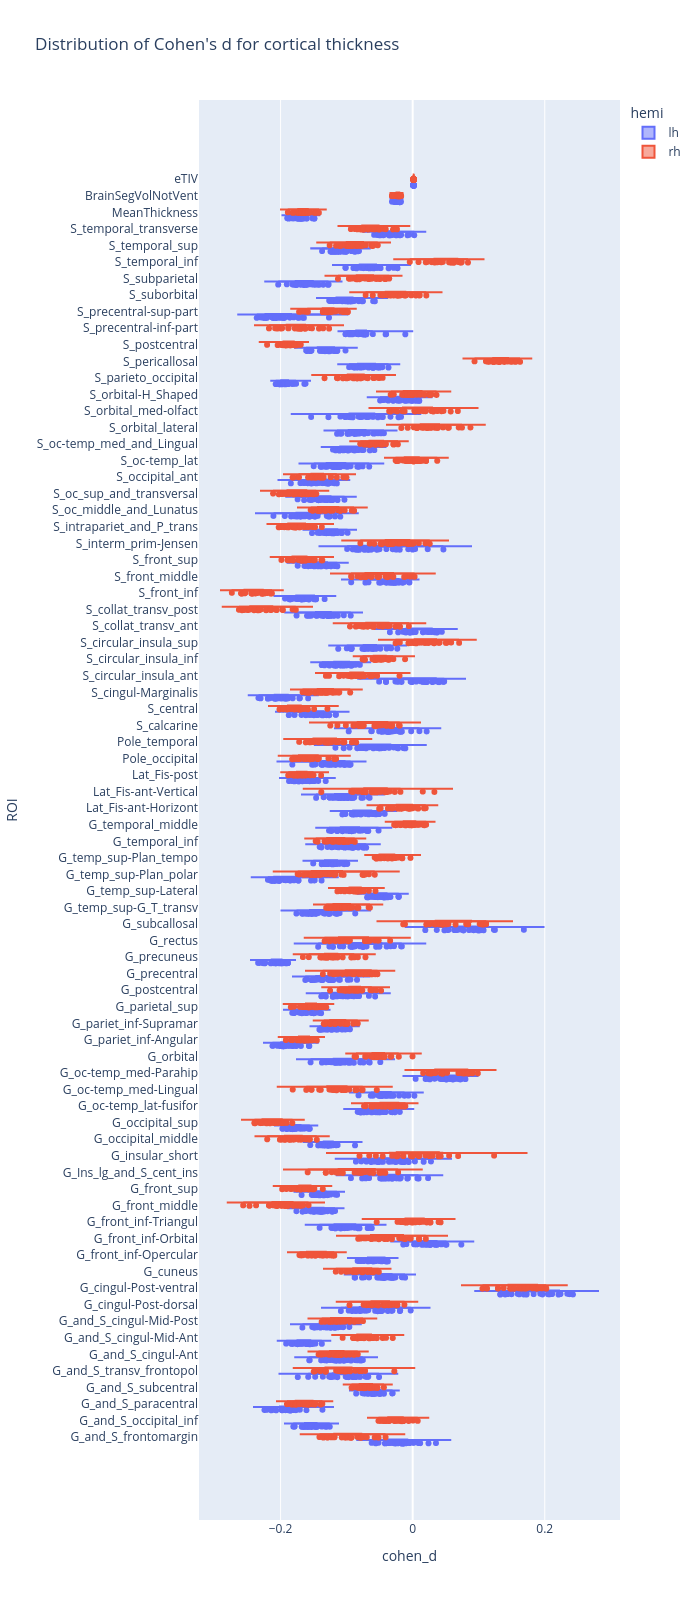

In [199]:
fig = px.violin(
    cohen_d_thickness,
    x="cohen_d",
    y="ROI",
    color="hemi",
    box=True,
    points="all",
    hover_data=["rep", "mean_pop1", "std_pop1", "var_pop1", "mean_pop2", "std_pop2", "var_pop2"],
    height=1600,
    title="Distribution of Cohen's d for cortical thickness",
).update_traces(orientation="h")
print_figure(fig, filename="figures/cohen_d_thickness.png")

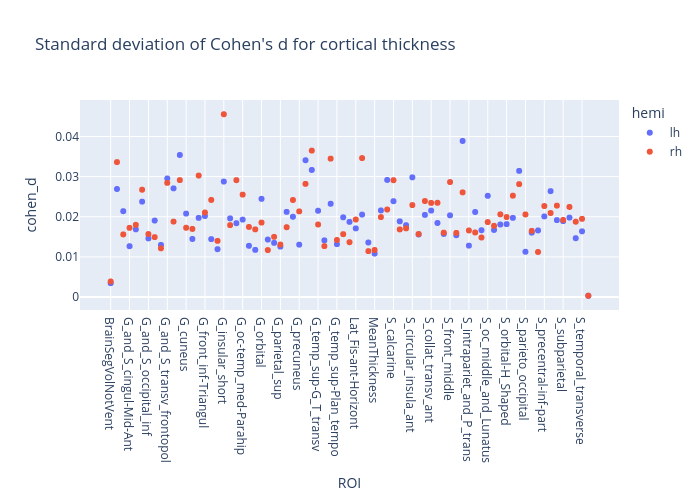

In [200]:
std_cohen_d = cohen_d_thickness.groupby(["hemi","ROI"])["cohen_d"].std().reset_index()
fig = px.scatter(
    std_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Standard deviation of Cohen's d for cortical thickness",
).update_traces(orientation="h")
print_figure(fig, filename="figures/std_cohen_d_thickness.png")

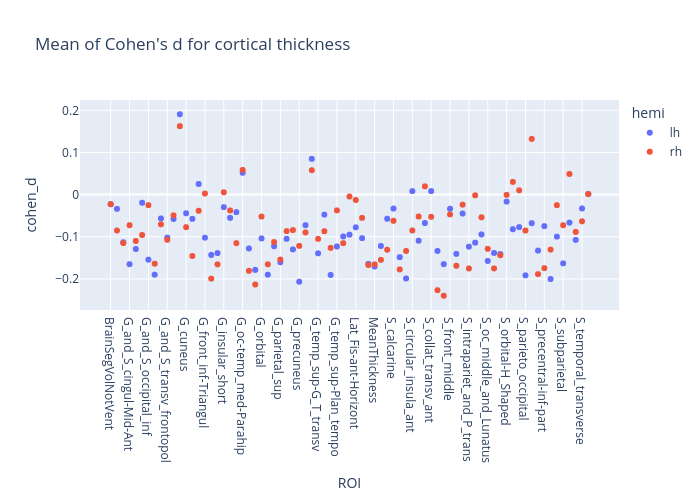

In [201]:
mean_cohen_d = cohen_d_thickness.groupby(["hemi","ROI"])["cohen_d"].mean().reset_index()
fig = px.scatter(
    mean_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Mean of Cohen's d for cortical thickness",
).update_traces(orientation="h")
print_figure(fig, filename="figures/mean_cohen_d_thickness.png")

### Surface Area

In [204]:
cohen_d_area = compute_cortical_variability_cohen_d("area", pop1, pop2)

/tmp/ipykernel_187744/2405758577.py:96: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



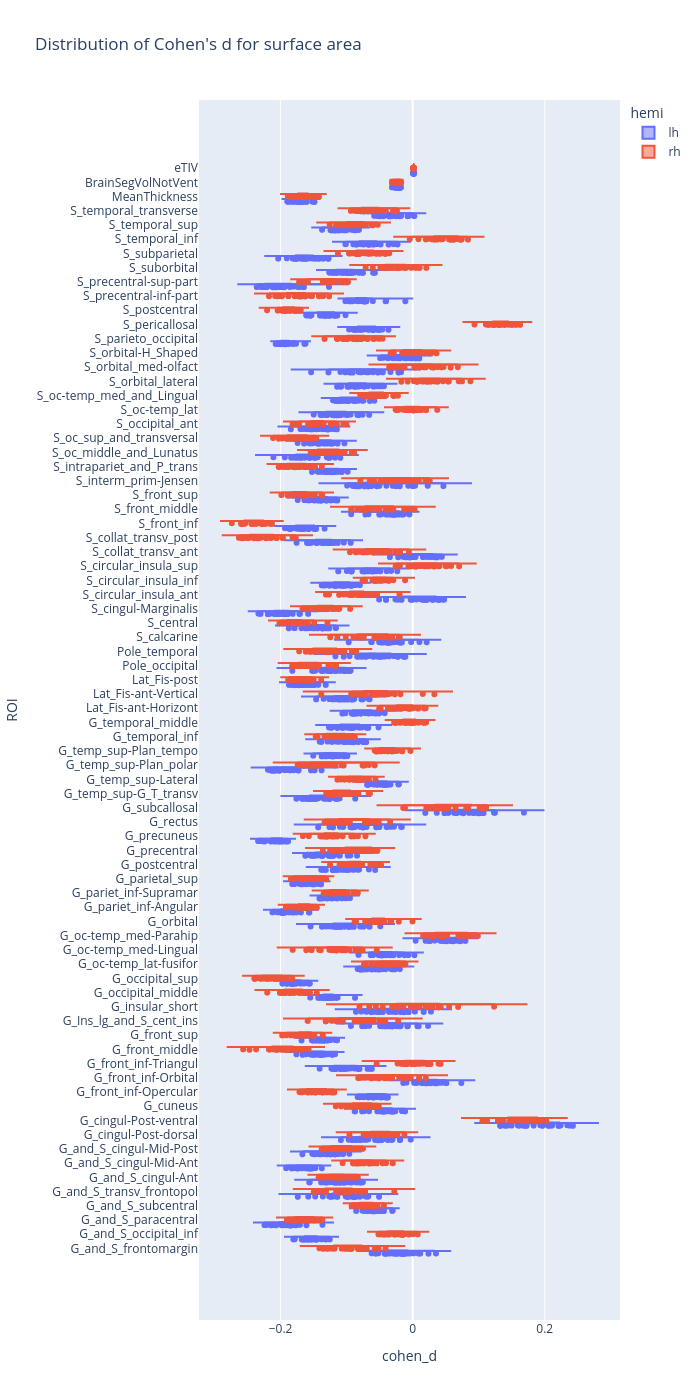

In [202]:
fig = px.violin(
    cohen_d_thickness,
    x="cohen_d",
    y="ROI",
    color="hemi",
    box=True,
    points="all",
    hover_data=["rep", "mean_pop1", "std_pop1", "var_pop1", "mean_pop2", "std_pop2", "var_pop2"],
    height=1400,
    title="Distribution of Cohen's d for surface area",
).update_traces(orientation="h")
print_figure(fig, filename="figures/cohen_d_area.png")

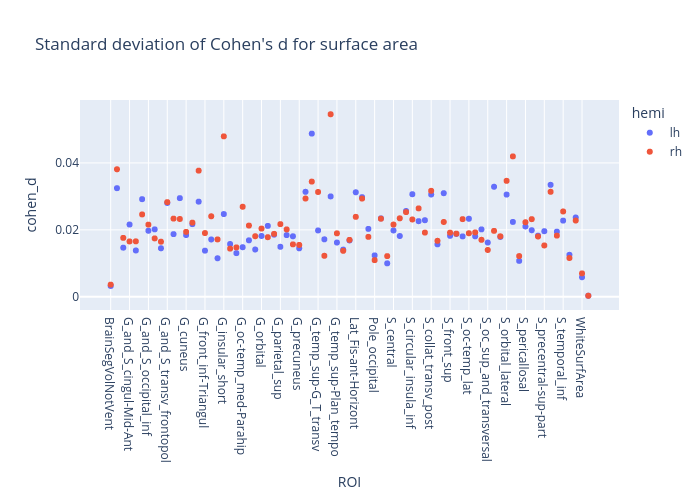

In [205]:
std_cohen_d = cohen_d_area.groupby(["hemi","ROI"])["cohen_d"].std().reset_index()
fig = px.scatter(
    std_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Standard deviation of Cohen's d for surface area",
).update_traces(orientation="h")
print_figure(fig, filename="figures/std_cohen_d_area.png")

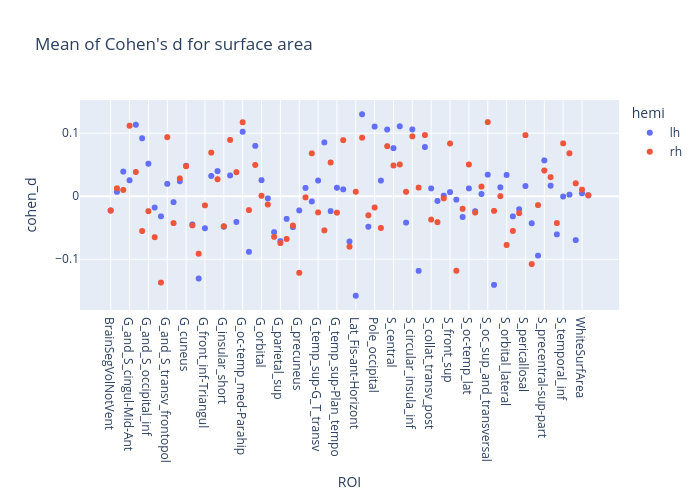

In [206]:
mean_cohen_d = cohen_d_area.groupby(["hemi","ROI"])["cohen_d"].mean().reset_index()
fig = px.scatter(
    mean_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Mean of Cohen's d for surface area",
).update_traces(orientation="h")
print_figure(fig, filename="figures/mean_cohen_d_area.png")

### Cortical Volume

In [207]:
cohen_d_volume = compute_cortical_variability_cohen_d("volume", pop1, pop2)

/tmp/ipykernel_187744/2405758577.py:96: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



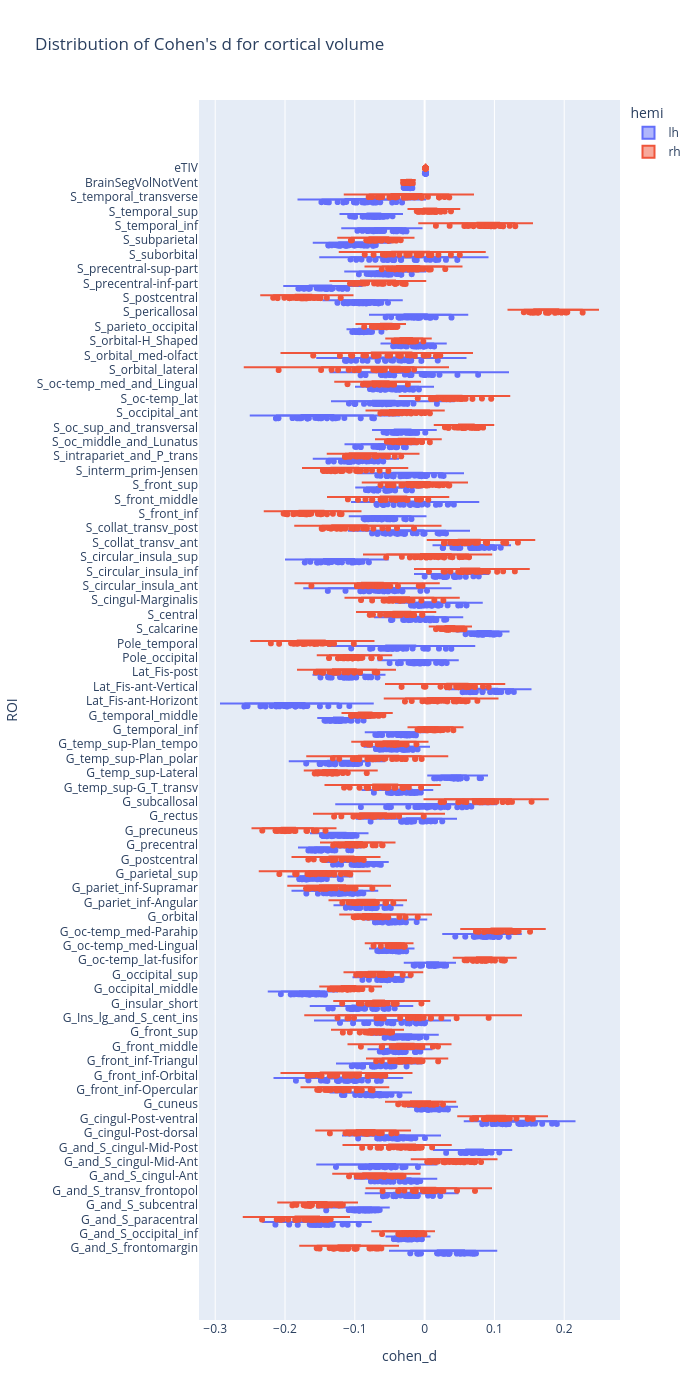

In [208]:
fig = px.violin(
    cohen_d_volume,
    x="cohen_d",
    y="ROI",
    color="hemi",
    box=True,
    points="all",
    hover_data=["rep", "mean_pop1", "std_pop1", "var_pop1", "mean_pop2", "std_pop2", "var_pop2"],
    height=1400,
    title="Distribution of Cohen's d for cortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/cohen_d_volume.png")

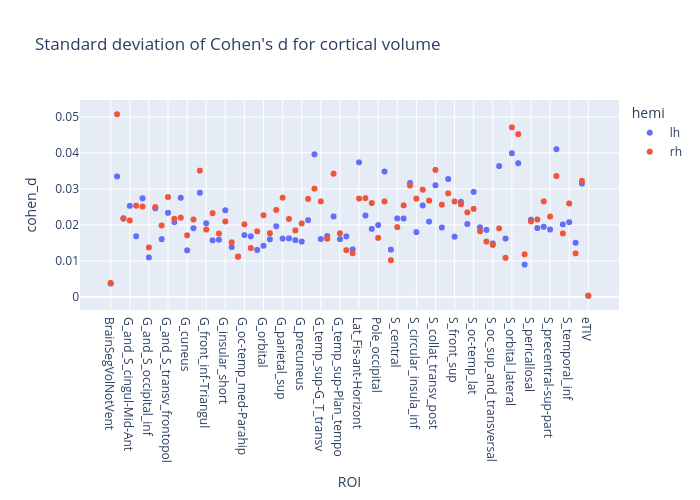

In [209]:
std_cohen_d = cohen_d_volume.groupby(["hemi","ROI"])["cohen_d"].std().reset_index()
fig = px.scatter(
    std_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Standard deviation of Cohen's d for cortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/std_cohen_d_volume.png")

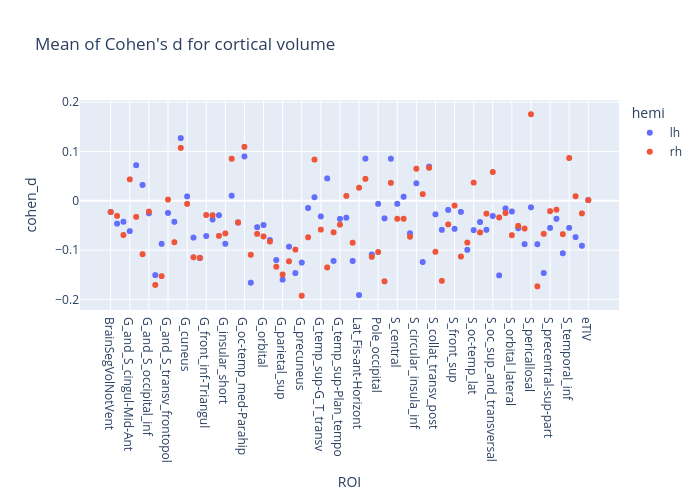

In [210]:
mean_cohen_d = cohen_d_volume.groupby(["hemi","ROI"])["cohen_d"].mean().reset_index()
fig = px.scatter(
    mean_cohen_d,
    x="ROI",
    y="cohen_d",
    color="hemi",
    hover_data=["cohen_d"],
    title="Mean of Cohen's d for cortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/mean_cohen_d_volume.png")

### Subcortical Volume

In [211]:
def compute_subcortical_variability_cohen_d(metric, population_1, population_2):
    """
    Computes Cohen's d for the given metric between two populations.
    """
    df = pd.read_parquet(stats_dir / f"{metric}.parquet")

    df = index_by_repetition(df)

    columns = [
        "rep",
        "ROI",
        "mean_pop1",
        "std_pop1",
        "var_pop1",
        "mean_pop2",
        "std_pop2",
        "var_pop2",
        "pooled_std",
        "cohen_d",
    ]
    cohen_d_df = pd.DataFrame(columns=columns)

    repetitions = df["Rep"].unique()
    for rep in repetitions:

        # Get population 1
        df1_rep = df[df["Rep"] == rep]
        df1_rep = df1_rep[df1_rep["subjects"].isin(population_1)]
        n1 = df1_rep["subjects"].nunique()
        # Compute mean, var, std for population 1
        
        mean_pop1 = compute_mean(df1_rep, hemi=None)
        var_pop1 = compute_var(df1_rep, hemi=False)
        std_pop1 = compute_std(df1_rep, hemi=False)

        # Get population 2
        df2_rep = df[df["Rep"] == rep]
        df2_rep = df2_rep[df2_rep["subjects"].isin(population_2)]
        n2 = df2_rep["subjects"].nunique()
        # Compute mean, var, std for population 2
        mean_pop2 = compute_mean(df2_rep, hemi=False)
        var_pop2 = compute_var(df2_rep, hemi=False)
        std_pop2 = compute_std(df2_rep, hemi=False)

        pooled_var = ((n1 - 1) * var_pop1.metric + (n2 - 1) * var_pop2.metric) / (
            n1 + n2 - 2
        )
        pooled_std = np.sqrt(pooled_var)
        cohen_d = (mean_pop1.metric - mean_pop2.metric) / pooled_std

        # Create a DataFrame to display the results
        cohen_d_df_rep = pd.DataFrame(columns=columns)
        cohen_d_df_rep["ROI"] = mean_pop1.ROI
        cohen_d_df_rep["mean_pop1"] = mean_pop1.metric
        cohen_d_df_rep["std_pop1"] = std_pop1.metric
        cohen_d_df_rep["var_pop1"] = var_pop1.metric
        cohen_d_df_rep["mean_pop2"] = mean_pop2.metric
        cohen_d_df_rep["std_pop2"] = std_pop2.metric
        cohen_d_df_rep["var_pop2"] = var_pop2.metric
        cohen_d_df_rep["pooled_std"] = pooled_std
        cohen_d_df_rep["cohen_d"] = cohen_d
        cohen_d_df_rep["rep"] = rep

        # Append the DataFrame to the main DataFrame
        cohen_d_df = pd.concat([cohen_d_df, cohen_d_df_rep], axis=0)

    cohen_d_df["ROI"] = cohen_d_df["ROI"].str.replace(f"_{metric}", "", regex=False)
    return cohen_d_df.reset_index(drop=True)


In [212]:
cohen_d_subcortical_volume = compute_subcortical_variability_cohen_d("subcortical_volume", pop1, pop2)
# Filter out ROI
roi_to_keep = [
    "Left-Accumbens-area",
    "Left-Amygdala",
    "Left-Caudate",
    "Left-Hippocampus",
    "Left-Pallidum",
    "Left-Putamen",
    "Left-Thalamus",
    "Left-Lateral-Ventricle",
    "Right-Accumbens-area",
    "Right-Amygdala",
    "Right-Caudate",
    "Right-Hippocampus",
    "Right-Pallidum",
    "Right-Putamen",
    "Right-Thalamus",
    "Right-Lateral-Ventricle",
]
cohen_d_subcortical_volume = cohen_d_subcortical_volume[
    cohen_d_subcortical_volume["ROI"].isin(roi_to_keep)
].reset_index(drop=True)

/tmp/ipykernel_187744/2584964131.py:65: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



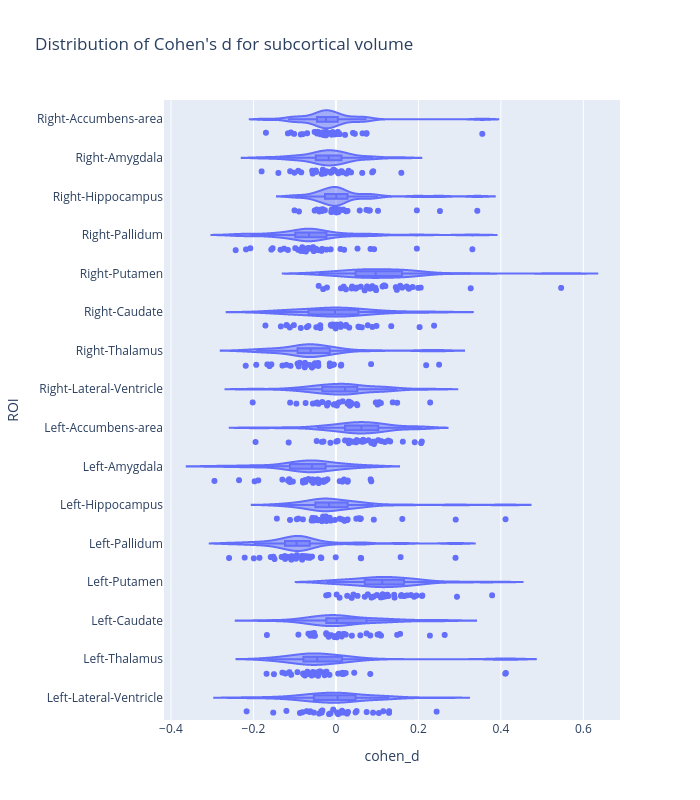

In [213]:
fig = px.violin(
    cohen_d_subcortical_volume,
    x="cohen_d",
    y="ROI",
    box=True,
    points="all",
    hover_data=["rep", "mean_pop1", "std_pop1", "var_pop1", "mean_pop2", "std_pop2", "var_pop2"],
    height=800,
    title="Distribution of Cohen's d for subcortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/cohen_d_subcortical_volume.png")

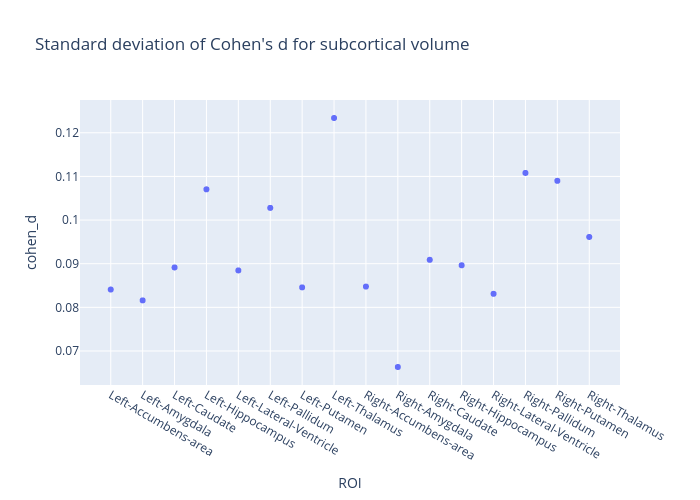

In [214]:
std_cohen_d = cohen_d_subcortical_volume.groupby(["ROI"])["cohen_d"].std().reset_index()
fig= px.scatter(
    std_cohen_d,
    x="ROI",
    y="cohen_d",
    hover_data=["cohen_d"],
    title="Standard deviation of Cohen's d for subcortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/std_cohen_d_subcortical_volume.png")

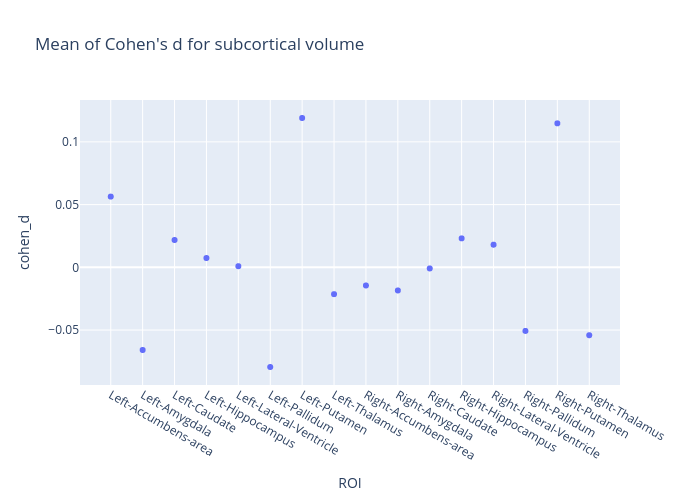

In [215]:
mean_cohen_d = cohen_d_subcortical_volume.groupby(["ROI"])["cohen_d"].mean().reset_index()
fig = px.scatter(
    mean_cohen_d,
    x="ROI",
    y="cohen_d",
    hover_data=["cohen_d"],
    title="Mean of Cohen's d for subcortical volume",
).update_traces(orientation="h")
print_figure(fig, filename="figures/mean_cohen_d_subcortical_volume.png")